In [26]:
# The project was supposed to use real-time analysis on amazoon reviews using amazon review scrapper. However, I am postpone the comments scrapping due to the new policies and limitations of Amazon. In this regard, the dataset from Kaggle website is used to proceed the project.

import pandas as pd
data = pd.read_csv("E:\Class\software\Mobile_Reviews_Sentiment.csv")
data.head()

,review_id,customer_name,age,brand,model,price_usd,price_local,currency,exchange_rate_to_usd,rating,...,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,review_length,word_count,helpful_votes,source
0,1,Aryan Maharaj,45,Realme,Realme 12 Pro,337.31,₹27996.73,INR,83.00,2,...,True,1,1,3,2,1,46,7,1,Amazon
1,2,Davi Miguel Sousa,18,Realme,Realme 12 Pro,307.78,R$1754.35,BRL,5.70,4,...,True,3,2,4,3,2,74,12,5,Flipkart
2,3,Pahal Balay,27,Google,Pixel 6,864.53,₹71755.99,INR,83.00,4,...,True,3,5,3,2,4,55,11,8,AliExpress
3,4,David Guzman,19,Xiaomi,Redmi Note 13,660.94,د.إ2425.65,AED,3.67,3,...,False,1,3,2,1,2,66,11,3,Amazon
4,5,Yago Leão,38,Motorola,Edge 50,792.13,R$4515.14,BRL,5.70,3,...,True,3,3,2,2,1,73,12,0,BestBuy


In [27]:
data = data[['review_text', 'sentiment']]

In [28]:
data.head()


,review_text,sentiment
0,Not worth the money spent. Wouldn’t recommend.,Negative
1,Absolutely love this phone! The camera is next...,Positive
2,Loving the clean UI and fast updates. Loving i...,Positive
3,Build quality feels solid and durable. No regr...,Positive
4,Not bad for daily use but could be optimized. ...,Neutral


In [29]:
import re

def cleancomments(comment):
    comment = re.sub('@[A-Za-z0-9_]+','',str(comment))
    comment = re.sub('https://[A-Za-z0-9./]+','',str(comment))
    comment = re.sub('#[A-Za-z0-9./]+','',str(comment))
    comment = re.sub(r'[^\w]', ' ', str(comment))
    comment = comment.lower()
    return comment


In [30]:
for index, row in data.iterrows():
    data.loc[index,'Cleancomment'] = cleancomments(data.loc[index,'review_text'])

data

,review_text,sentiment,Cleancomment
0,Not worth the money spent. Wouldn’t recommend.,Negative,not worth the money spent wouldn t recommend
1,Absolutely love this phone! The camera is next...,Positive,absolutely love this phone the camera is next...
2,Loving the clean UI and fast updates. Loving i...,Positive,loving the clean ui and fast updates loving i...
3,Build quality feels solid and durable. No regr...,Positive,build quality feels solid and durable no regr...
4,Not bad for daily use but could be optimized. ...,Neutral,not bad for daily use but could be optimized ...
...,...,...,...
49995,Battery easily lasts a day with heavy use. Lov...,Positive,battery easily lasts a day with heavy use lov...
49996,Battery life could be slightly better. Fine bu...,Neutral,battery life could be slightly better fine bu...
49997,"Face unlock is instant, super smooth. Best pur...",Positive,face unlock is instant super smooth best pur...
49998,Build quality feels solid and durable. Loving ...,Positive,build quality feels solid and durable loving ...


In [31]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(nltk.corpus.stopwords.words('english'))



[nltk_data] Downloading package stopwords to C:\Users\V I S I O
[nltk_data]     N\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [32]:
data['applied stop_words'] = data['Cleancomment'].apply(lambda x: ' '.join([comment for comment in x.split() if comment not in (stop_words)]))
data

,review_text,sentiment,Cleancomment,applied stop_words
0,Not worth the money spent. Wouldn’t recommend.,Negative,not worth the money spent wouldn t recommend,worth money spent recommend
1,Absolutely love this phone! The camera is next...,Positive,absolutely love this phone the camera is next...,absolutely love phone camera next level absolu...
2,Loving the clean UI and fast updates. Loving i...,Positive,loving the clean ui and fast updates loving i...,loving clean ui fast updates loving far
3,Build quality feels solid and durable. No regr...,Positive,build quality feels solid and durable no regr...,build quality feels solid durable regrets buyi...
4,Not bad for daily use but could be optimized. ...,Neutral,not bad for daily use but could be optimized ...,bad daily use could optimized average experien...
...,...,...,...,...
49995,Battery easily lasts a day with heavy use. Lov...,Positive,battery easily lasts a day with heavy use lov...,battery easily lasts day heavy use loving far
49996,Battery life could be slightly better. Fine bu...,Neutral,battery life could be slightly better fine bu...,battery life could slightly better fine could ...
49997,"Face unlock is instant, super smooth. Best pur...",Positive,face unlock is instant super smooth best pur...,face unlock instant super smooth best purchase...
49998,Build quality feels solid and durable. Loving ...,Positive,build quality feels solid and durable loving ...,build quality feels solid durable loving far


In [33]:
import nltk
from nltk.tokenize import word_tokenize
data['tokenized_Comments'] = data.apply(lambda row: nltk.word_tokenize(row['applied stop_words']), axis=1)

In [34]:
data

,review_text,sentiment,Cleancomment,applied stop_words,tokenized_Comments
0,Not worth the money spent. Wouldn’t recommend.,Negative,not worth the money spent wouldn t recommend,worth money spent recommend,"[worth, money, spent, recommend]"
1,Absolutely love this phone! The camera is next...,Positive,absolutely love this phone the camera is next...,absolutely love phone camera next level absolu...,"[absolutely, love, phone, camera, next, level,..."
2,Loving the clean UI and fast updates. Loving i...,Positive,loving the clean ui and fast updates loving i...,loving clean ui fast updates loving far,"[loving, clean, ui, fast, updates, loving, far]"
3,Build quality feels solid and durable. No regr...,Positive,build quality feels solid and durable no regr...,build quality feels solid durable regrets buyi...,"[build, quality, feels, solid, durable, regret..."
4,Not bad for daily use but could be optimized. ...,Neutral,not bad for daily use but could be optimized ...,bad daily use could optimized average experien...,"[bad, daily, use, could, optimized, average, e..."
...,...,...,...,...,...
49995,Battery easily lasts a day with heavy use. Lov...,Positive,battery easily lasts a day with heavy use lov...,battery easily lasts day heavy use loving far,"[battery, easily, lasts, day, heavy, use, lovi..."
49996,Battery life could be slightly better. Fine bu...,Neutral,battery life could be slightly better fine bu...,battery life could slightly better fine could ...,"[battery, life, could, slightly, better, fine,..."
49997,"Face unlock is instant, super smooth. Best pur...",Positive,face unlock is instant super smooth best pur...,face unlock instant super smooth best purchase...,"[face, unlock, instant, super, smooth, best, p..."
49998,Build quality feels solid and durable. Loving ...,Positive,build quality feels solid and durable loving ...,build quality feels solid durable loving far,"[build, quality, feels, solid, durable, loving..."


In [35]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

nltk.download('punkt')
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()

data['lemmatized_Comments'] = data['tokenized_Comments'].apply(
    lambda tokens: [lemmatizer.lemmatize(token) for token in tokens]
)

[nltk_data] Downloading package punkt to C:\Users\V I S I O
[nltk_data]     N\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\V I S I O
[nltk_data]     N\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [36]:
data

,review_text,sentiment,Cleancomment,applied stop_words,tokenized_Comments,lemmatized_Comments
0,Not worth the money spent. Wouldn’t recommend.,Negative,not worth the money spent wouldn t recommend,worth money spent recommend,"[worth, money, spent, recommend]","[worth, money, spent, recommend]"
1,Absolutely love this phone! The camera is next...,Positive,absolutely love this phone the camera is next...,absolutely love phone camera next level absolu...,"[absolutely, love, phone, camera, next, level,...","[absolutely, love, phone, camera, next, level,..."
2,Loving the clean UI and fast updates. Loving i...,Positive,loving the clean ui and fast updates loving i...,loving clean ui fast updates loving far,"[loving, clean, ui, fast, updates, loving, far]","[loving, clean, ui, fast, update, loving, far]"
3,Build quality feels solid and durable. No regr...,Positive,build quality feels solid and durable no regr...,build quality feels solid durable regrets buyi...,"[build, quality, feels, solid, durable, regret...","[build, quality, feel, solid, durable, regret,..."
4,Not bad for daily use but could be optimized. ...,Neutral,not bad for daily use but could be optimized ...,bad daily use could optimized average experien...,"[bad, daily, use, could, optimized, average, e...","[bad, daily, use, could, optimized, average, e..."
...,...,...,...,...,...,...
49995,Battery easily lasts a day with heavy use. Lov...,Positive,battery easily lasts a day with heavy use lov...,battery easily lasts day heavy use loving far,"[battery, easily, lasts, day, heavy, use, lovi...","[battery, easily, last, day, heavy, use, lovin..."
49996,Battery life could be slightly better. Fine bu...,Neutral,battery life could be slightly better fine bu...,battery life could slightly better fine could ...,"[battery, life, could, slightly, better, fine,...","[battery, life, could, slightly, better, fine,..."
49997,"Face unlock is instant, super smooth. Best pur...",Positive,face unlock is instant super smooth best pur...,face unlock instant super smooth best purchase...,"[face, unlock, instant, super, smooth, best, p...","[face, unlock, instant, super, smooth, best, p..."
49998,Build quality feels solid and durable. Loving ...,Positive,build quality feels solid and durable loving ...,build quality feels solid durable loving far,"[build, quality, feels, solid, durable, loving...","[build, quality, feel, solid, durable, loving,..."


In [37]:
#https://github.com/clieb3/pos-tagger-comparison/blob/master/tagger-comparison.ipynb
#paper: Tagging Efficiency Analysis on Part of Speech Taggers

from nltk.tag.perceptron import PerceptronTagger

nltk.download('averaged_perceptron_tagger')

tagger = PerceptronTagger()

data['pos_tags'] = data['lemmatized_Comments'].apply (lambda tokens: tagger.tag(tokens))

data

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\V I S I O N\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


,review_text,sentiment,Cleancomment,applied stop_words,tokenized_Comments,lemmatized_Comments,pos_tags
0,Not worth the money spent. Wouldn’t recommend.,Negative,not worth the money spent wouldn t recommend,worth money spent recommend,"[worth, money, spent, recommend]","[worth, money, spent, recommend]","[(worth, JJ), (money, NN), (spent, VBN), (reco..."
1,Absolutely love this phone! The camera is next...,Positive,absolutely love this phone the camera is next...,absolutely love phone camera next level absolu...,"[absolutely, love, phone, camera, next, level,...","[absolutely, love, phone, camera, next, level,...","[(absolutely, RB), (love, VB), (phone, NN), (c..."
2,Loving the clean UI and fast updates. Loving i...,Positive,loving the clean ui and fast updates loving i...,loving clean ui fast updates loving far,"[loving, clean, ui, fast, updates, loving, far]","[loving, clean, ui, fast, update, loving, far]","[(loving, VBG), (clean, JJ), (ui, JJ), (fast, ..."
3,Build quality feels solid and durable. No regr...,Positive,build quality feels solid and durable no regr...,build quality feels solid durable regrets buyi...,"[build, quality, feels, solid, durable, regret...","[build, quality, feel, solid, durable, regret,...","[(build, JJ), (quality, NN), (feel, VBP), (sol..."
4,Not bad for daily use but could be optimized. ...,Neutral,not bad for daily use but could be optimized ...,bad daily use could optimized average experien...,"[bad, daily, use, could, optimized, average, e...","[bad, daily, use, could, optimized, average, e...","[(bad, JJ), (daily, JJ), (use, NN), (could, MD..."
...,...,...,...,...,...,...,...
49995,Battery easily lasts a day with heavy use. Lov...,Positive,battery easily lasts a day with heavy use lov...,battery easily lasts day heavy use loving far,"[battery, easily, lasts, day, heavy, use, lovi...","[battery, easily, last, day, heavy, use, lovin...","[(battery, NN), (easily, RB), (last, JJ), (day..."
49996,Battery life could be slightly better. Fine bu...,Neutral,battery life could be slightly better fine bu...,battery life could slightly better fine could ...,"[battery, life, could, slightly, better, fine,...","[battery, life, could, slightly, better, fine,...","[(battery, NN), (life, NN), (could, MD), (slig..."
49997,"Face unlock is instant, super smooth. Best pur...",Positive,face unlock is instant super smooth best pur...,face unlock instant super smooth best purchase...,"[face, unlock, instant, super, smooth, best, p...","[face, unlock, instant, super, smooth, best, p...","[(face, NN), (unlock, NN), (instant, JJ), (sup..."
49998,Build quality feels solid and durable. Loving ...,Positive,build quality feels solid and durable loving ...,build quality feels solid durable loving far,"[build, quality, feels, solid, durable, loving...","[build, quality, feel, solid, durable, loving,...","[(build, JJ), (quality, NN), (feel, VBP), (sol..."


In [38]:
def extract_nouns(pos_tags):
    if not isinstance(pos_tags, list):
        return []
    return [word for word, tag in pos_tags if tag.startswith('NN')]


In [39]:
data['nouns'] = data['pos_tags'].apply(extract_nouns)
data


,review_text,sentiment,Cleancomment,applied stop_words,tokenized_Comments,lemmatized_Comments,pos_tags,nouns
0,Not worth the money spent. Wouldn’t recommend.,Negative,not worth the money spent wouldn t recommend,worth money spent recommend,"[worth, money, spent, recommend]","[worth, money, spent, recommend]","[(worth, JJ), (money, NN), (spent, VBN), (reco...","[money, recommend]"
1,Absolutely love this phone! The camera is next...,Positive,absolutely love this phone the camera is next...,absolutely love phone camera next level absolu...,"[absolutely, love, phone, camera, next, level,...","[absolutely, love, phone, camera, next, level,...","[(absolutely, RB), (love, VB), (phone, NN), (c...","[phone, camera, level]"
2,Loving the clean UI and fast updates. Loving i...,Positive,loving the clean ui and fast updates loving i...,loving clean ui fast updates loving far,"[loving, clean, ui, fast, updates, loving, far]","[loving, clean, ui, fast, update, loving, far]","[(loving, VBG), (clean, JJ), (ui, JJ), (fast, ...","[fast, update, loving]"
3,Build quality feels solid and durable. No regr...,Positive,build quality feels solid and durable no regr...,build quality feels solid durable regrets buyi...,"[build, quality, feels, solid, durable, regret...","[build, quality, feel, solid, durable, regret,...","[(build, JJ), (quality, NN), (feel, VBP), (sol...","[quality, buying]"
4,Not bad for daily use but could be optimized. ...,Neutral,not bad for daily use but could be optimized ...,bad daily use could optimized average experien...,"[bad, daily, use, could, optimized, average, e...","[bad, daily, use, could, optimized, average, e...","[(bad, JJ), (daily, JJ), (use, NN), (could, MD...","[use, experience]"
...,...,...,...,...,...,...,...,...
49995,Battery easily lasts a day with heavy use. Lov...,Positive,battery easily lasts a day with heavy use lov...,battery easily lasts day heavy use loving far,"[battery, easily, lasts, day, heavy, use, lovi...","[battery, easily, last, day, heavy, use, lovin...","[(battery, NN), (easily, RB), (last, JJ), (day...","[battery, day, use]"
49996,Battery life could be slightly better. Fine bu...,Neutral,battery life could be slightly better fine bu...,battery life could slightly better fine could ...,"[battery, life, could, slightly, better, fine,...","[battery, life, could, slightly, better, fine,...","[(battery, NN), (life, NN), (could, MD), (slig...","[battery, life, fine]"
49997,"Face unlock is instant, super smooth. Best pur...",Positive,face unlock is instant super smooth best pur...,face unlock instant super smooth best purchase...,"[face, unlock, instant, super, smooth, best, p...","[face, unlock, instant, super, smooth, best, p...","[(face, NN), (unlock, NN), (instant, JJ), (sup...","[face, unlock, smooth, purchase, year]"
49998,Build quality feels solid and durable. Loving ...,Positive,build quality feels solid and durable loving ...,build quality feels solid durable loving far,"[build, quality, feels, solid, durable, loving...","[build, quality, feel, solid, durable, loving,...","[(build, JJ), (quality, NN), (feel, VBP), (sol...","[quality, loving]"


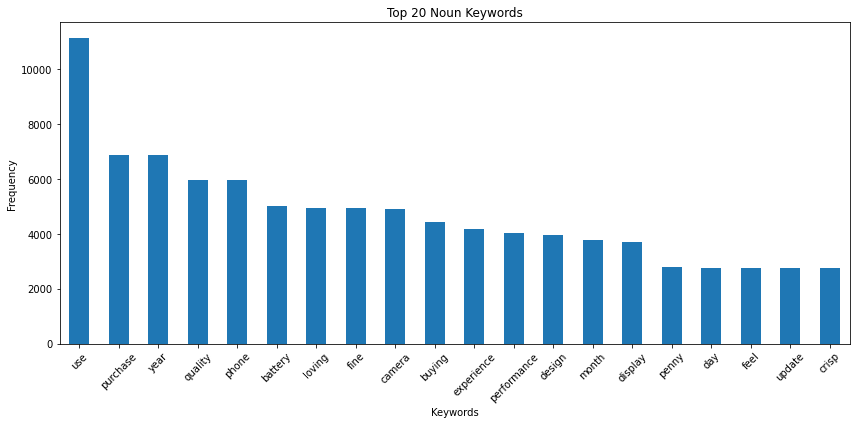

In [40]:
import matplotlib.pyplot as plt

noun_counts = data['nouns'].explode().value_counts().head(20)
plt.figure(figsize=(12,6))
noun_counts.plot(kind='bar')
plt.xlabel('Keywords')
plt.ylabel('Frequency')
plt.title('Top 20 Noun Keywords')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [41]:
useless_aspects = [
    'phone','year','loving','fine','month',
    'penny','day','feel','crisp'
]

noun_counts = (
    data['nouns']
    .explode()
    .loc[lambda x: ~x.isin(useless_aspects)]
    .value_counts()
    .head(20)
)


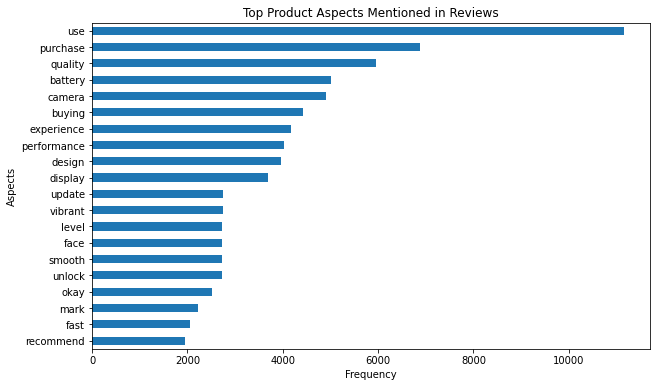

In [42]:
plt.figure(figsize=(10,6))
noun_counts.sort_values().plot(kind='barh')
plt.title('Top Product Aspects Mentioned in Reviews')
plt.xlabel('Frequency')
plt.ylabel('Aspects')

plt.show()

In [43]:
import nltk
def get_all_phrases_containing_tar_wrd(target_word, tar_passage, left_margin = 5, right_margin = 5):
    tokens = nltk.word_tokenize(tar_passage)
    tokens = [x for x in tokens if len(x)>2] 
    text = nltk.Text(tokens)
    c = nltk.ConcordanceIndex(text.tokens, key = lambda s: s.lower())
    concordance_txt = ([text.tokens[  list(map(lambda x: x-5 if (x-left_margin)>0 else 0,[offset]))[0]:offset+right_margin] for offset in c.offsets(target_word)])
    return [''.join([x+' ' for x in con_sub]) for con_sub in concordance_txt]

In [48]:
from nltk import sent_tokenize

reviews = data['Cleancomment'].dropna().astype(str)
relevant_aspects = ['battery', 'price', 'quality', 'performance']

phrases = []
aspects = []
review_ids = []

counter = 0

for idx, review in reviews.items():  # ⭐ KEY FIX
    try:
        for sentence in sent_tokenize(review):
            for important_word in relevant_aspects:
                phrases_in_sentence = get_all_phrases_containing_tar_wrd(
                    important_word, sentence, left_margin=5, right_margin=5
                )
                for phrase in phrases_in_sentence:
                    aspect = 'other'
                    for imp_word in relevant_aspects:
                        if imp_word in phrase.lower():
                            aspect = imp_word

                    aspects.append(aspect)
                    phrases.append(phrase)
                    review_ids.append(idx)

    except:
        pass
    counter += 1
phrasesDF = pd.DataFrame({
    'review_id': review_ids,
    'aspect': aspects
})

phrasesDF = phrasesDF.merge(
    data[['review_text', 'sentiment']],
    left_on='review_id',
    right_index=True,
    how='left'
)[['review_text', 'sentiment', 'aspect']]

phrasesDF.head()

,review_text,sentiment,aspect
0,Build quality feels solid and durable. No regr...,Positive,quality
1,Battery easily lasts a day with heavy use. No ...,Positive,battery
2,Battery easily lasts a day with heavy use. Lov...,Positive,battery
3,Smooth performance even after months of use. N...,Positive,performance
4,Battery easily lasts a day with heavy use. No ...,Positive,battery


In [51]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer 
vader_sentiment = []  
vader_sentiment_neg = [] 
vader_sentiment_pos = []
sid = SentimentIntensityAnalyzer()
for sentence in phrasesDF['review_text']:
    try:
        vader_sentiment.append(sid.polarity_scores(sentence)['compound'])
        vader_sentiment_pos.append(sid.polarity_scores(sentence)['pos'])
        vader_sentiment_neg.append(sid.polarity_scores(sentence)['neg'])
    except:
        vader_sentiment.append(0.5)
phrasesDF['vader_sentiment'] = pd.Series(vader_sentiment)   
phrasesDF['vader_sentiment_neg'] = pd.Series(vader_sentiment_neg)   
phrasesDF['vader_sentiment_pos'] = pd.Series(vader_sentiment_pos)

In [52]:
phrasesDF

,review_text,sentiment,aspect,vader_sentiment,vader_sentiment_neg,vader_sentiment_pos
0,Build quality feels solid and durable. No regr...,Positive,quality,-0.4767,0.329,0.112
1,Battery easily lasts a day with heavy use. No ...,Positive,battery,-0.3182,0.292,0.149
2,Battery easily lasts a day with heavy use. Lov...,Positive,battery,0.7644,0.000,0.423
3,Smooth performance even after months of use. N...,Positive,performance,-0.5719,0.320,0.000
4,Battery easily lasts a day with heavy use. No ...,Positive,battery,-0.3182,0.292,0.149
...,...,...,...,...,...,...
16315,Battery life could be slightly better. Okay fo...,Neutral,battery,0.6160,0.000,0.463
16316,Speaker quality is bad and muffled. Wouldn’t r...,Negative,quality,-0.2500,0.292,0.208
16317,Battery easily lasts a day with heavy use. Lov...,Positive,battery,0.7644,0.000,0.423
16318,Battery life could be slightly better. Fine bu...,Neutral,battery,0.6678,0.000,0.447


In [54]:
phrasesDF['sentiment'] = phrasesDF['vader_sentiment'].apply(lambda score: 'positive' if score>=0.05 else 'negative' if score<=-0.05 else 'neutral')
phrasesDF = phrasesDF.drop(columns=['vader_sentiment_neg', 'vader_sentiment_pos'], errors='ignore')
phrasesDF.head()

,review_text,sentiment,aspect,vader_sentiment
0,Build quality feels solid and durable. No regr...,negative,quality,-0.4767
1,Battery easily lasts a day with heavy use. No ...,negative,battery,-0.3182
2,Battery easily lasts a day with heavy use. Lov...,positive,battery,0.7644
3,Smooth performance even after months of use. N...,negative,performance,-0.5719
4,Battery easily lasts a day with heavy use. No ...,negative,battery,-0.3182
